PROJECT: ASTEROID THREAT PREDICTION
    
VIVEK AGGARWAL    
    
Introduction
        
     Dataset Source
     The dataset that we have used for this project is from Kaggle. This dataset comprises of the potential hazard that asteroids impose on the earth 
     
 Dataset Details
     
     This dataset contains information on near-approach data and numerous features of Near Earth Objects (NEOs). The Neo Reference ID, Name, Absolute Magnitude, Estimated Diameter in KM, Close Approach Date, Relative Velocity km/h, Miss Distance, Orbiting Body, and Hazardous status are just a few of the columns that are included in the dataset. Every article contains comprehensive details about a particular NEO, such as its size, speed, the distance it misses Earth, and whether or not it is thought to be potentially dangerous. Understanding and keeping an eye on NEOs that could endanger Earth depends on this data.
     
 Dataset Retrival 
     
        We read in the dataset from  kaggle and load the modules we will use throughout this report.
We display 10 randomly sampled rows from this dataset.

Target Feature 

    For this project, the target feature in this dataset will be the boolean value in hazardeous coloumn. That is, the chances of asteroids collision with earth based on given data

Goals & Objectives

    The examination of near-Earth asteroids (NEAs) is crucial for comprehending possible hazards to Earth and investigating prospects for upcoming space expeditions. Our project intends to improve our capacity to evaluate potential impact trajectories of NEAs and guide mitigation actions by utilizing machine learning approaches to forecast the essential attributes of NEAs. Our goals are specifically as follows:

    Understanding and Preprocessing of the Dataset: Our main objective is to fully comprehend the NEA dataset, including its orbital parameters, physical properties, and any other pertinent elements. We plan to perform thorough preparation on the data to guarantee that it is uncontaminated, standardized, and ready for analysis. This includes managing outliers, missing data, and any other abnormalities that can have an impact on our predictive models' accuracy.

    Exploratory Data Analysis (EDA): We aim to conduct comprehensive exploratory data analysis to uncover patterns, trends, and relationships within the NEA dataset. We want to obtain insights into the distribution of NEA features and their possible correlations with other factors through statistical summaries, visualizations, and other EDA tools.

    Engineering and Feature Selection: Another key objective is to identify the most informative features that contribute to predicting the characteristics of NEAs. We will explore various feature selection techniques to determine the subset of features that have the most significant impact on predicting attributes such as size, composition, and orbital dynamics. Additionally, we may engage in feature engineering to create new variables or transform existing ones to enhance the predictive power of our models.

    Documentation and Reporting: It is essential for us to document our methodology and findings effectively. We aim to create a comprehensive report in a Jupyter Notebook environment, detailing each step of our analysis, from data preprocessing to model evaluation. Clear and transparent documentation will facilitate reproducibility and enable others to build upon our work in the field of asteroid research.

    By achieving these objectives, we aim to develop robust predictive models that can accurately forecast key characteristics of NEAs based on the provided dataset. Our ultimate goal is to contribute to the advancement of asteroid science and planetary defense efforts by employing machine learning techniques to enhance our understanding of these celestial bodies. Through this project, we seek to demonstrate proficiency in applying data science methodologies to tackle challenges in space exploration and planetary defense.

In [22]:
import warnings
warnings.filterwarnings("ignore")


import numpy as np
import pandas as pd
import tabulate as tabulate

pd.set_option('display.max_columns', None) 

import matplotlib.pyplot as plt
import seaborn as sns



In [23]:
df = pd.read_csv(r"nasa.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\vivek\\OneDrive\\Desktop\\nasa.csv'

In [ ]:
df.head()

In [ ]:
df.describe

Dataset features

the features in our dataset are described in the table below 

    In this instance, we generated a tabular overview of the dataset's columns, along by descriptions, data types, and units. The dataset's columns are represented by each row in the table, which has the following columns: "Column Name," "Data type," "Units," and "Description." The names of the columns in the dataset are listed in the "Column Name" column. Each column's data type (such as integer, float, object, or boolean) is specified in the "Data type" column. According to the "Units" column, the measuring units (e.g., kilometers, meters, miles, astronomical units) for number columns when appropriate. Lastly, a brief explanation of each column's relevance or the data it represents in the dataset is given in the "Description" column. This tabular summary provides a thorough rundown of the structure of the data and its columns description that assists us in understanding

In [24]:
from tabulate import tabulate 

table= [['Coloumn Name', ' Data type','Units', 'Description'],
        ['Neo Reference ID ', ' integer','NA', 'Reference id for asteroids'],
        ['Name', ' integer','NA', 'Name of the Asteoids'],
        ['Absolute Magnitude ', 'float','NA', 'The absolute magnitude of the Near Earth Objecta,'],
        ['Est Dia in KM(min)', 'float','Km', 'The minimum estimated diameter of the NEO in kilometers'],
        ['Est Dia in KM(max)  ', 'float','Km', 'The maximum estimated diameter of the NEO in kilometers.'],
        ['Est Dia in M(min)', 'float','Metre', 'The minimum estimated diameter of the NEO in meters'],
        ['Est Dia in M(max', 'float','Metre', 'The maximum estimated diameter of the NEO in meters.'],
        ['Est Dia in Miles(min)', 'float','Miles', 'The minimum estimated diameter of the NEO in miles.'],
        ['Est Dia in Miles(max): ', 'float','Miles', 'The maximum estimated diameter of the NEO in miles.'],
        ['Est Dia in Feet(min)', 'float','Feet', 'The minimum estimated diameter of the NEO in feet.'],
        ['Est Dia in Feet(max)', 'float','Feet', 'The maximum estimated diameter of the NEO in feet.'],
        ['Close Approach Date', 'object','NA', 'The date of the closest approach of the NEO to Earth.'],
        ['Epoch Date Close Approach', 'float','NA', 'The epoch date of the closest approach.'],
        ['Relative Velocity km per sec', 'float','Km/s', 'The relative velocity of the NEO with respect to Earth in kilometers per second.'],
        ['Relative Velocity km per hr', 'float','km/h', 'The relative velocity of the NEO with respect to Earth in kilometers per hour.'],
        ['Miles per hour', 'float', 'Miles/hr','The relative velocity of the NEO with respect to Earth in miles per hour.'],
        ['Miss Dist.(Astronomical)', 'float','NA', 'The miss distance of the NEO with respect to Earth in astronomical units.'],
        ['Miss Dist.(lunar)', 'float','NA', 'The miss distance of the NEO with respect to Earth in lunar distances.'],
        ['Miss Dist.(kilometers)', 'float', 'Km','The miss distance of the NEO with respect to Earth in kilometers.'],
        ['Miss Dist.(miles)', 'float','Miles', 'The miss distance of the NEO with respect to Earth in miles.'],
        ['Orbiting Body', ' object','NA', 'The celestial body around which the NEO is orbiting (e.g., Earth).'],
        ['Orbit ID', ' Integer','NA', 'The ID of the orbit'],
        ['Orbit Determination Date', ' object','NA', 'The date of orbit determination.'],
        ['Orbit Uncertainty', ' Integer','NA', 'The uncertainty associated with the orbit determination.'],
        ['Minimum Orbit Intersection', ' float','NA', 'The minimum orbit intersection distance'],
        ['Jupiter Tisserand Invariant', ' float','NA', ' The Jupiter Tisserand Invariant.'],
        ['Epoch Osculation', ' float', 'NA','The epoch osculation.'],
        ['Eccentricity', ' float','NA', 'The eccentricity of the NEO orbit'],
        ['Semi Major Axis', ' float','NA', 'The semi-major axis of the NEO orbit.'],
        ['Inclination', ' float','Angle', ' The inclination of the NEOs orbit'],
        ['Asc Node Longitude', 'float', 'NA','The ascending node longitude of the NEOs orbit.'],
        ['Orbital Period', 'float','NA', 'The orbital period of the NEO'],
        ['Perihelion Distance', 'float','Au', 'The perihelion distance of the NEO orbit'],
        ['Perihelion Arg', 'float','NA', 'The perihelion argument of the NEO orbit.'],
        ['Aphelion Dist', 'float', 'Au','The aphelion distance of the NEO orbit'],
        ['Perihelion Time', 'float','NA', 'The perihelion time of the NEO orbit'],
        ['Mean Anomaly','float','NA', 'The mean anomaly of the NEO orbit.'],
        ['Mean Motion','float','NA', 'The mean motion of the NEO orbit.'],
        ['Equinox','float','NA', 'The equinox of the data.'],
        ['Hazardous','boolean','NA', 'Indicates whether the NEO is classified as hazardous (TRUE/FALSE)']]



In [25]:
print(tabulate(table,headers='firstrow', tablefmt= 'fancy_grid'))

╒══════════════════════════════╤══════════════╤══════════╤══════════════════════════════════════════════════════════════════════════════════╕
│ Coloumn Name                 │  Data type   │ Units    │ Description                                                                      │
╞══════════════════════════════╪══════════════╪══════════╪══════════════════════════════════════════════════════════════════════════════════╡
│ Neo Reference ID             │ integer      │ NA       │ Reference id for asteroids                                                       │
├──────────────────────────────┼──────────────┼──────────┼──────────────────────────────────────────────────────────────────────────────────┤
│ Name                         │ integer      │ NA       │ Name of the Asteoids                                                             │
├──────────────────────────────┼──────────────┼──────────┼──────────────────────────────────────────────────────────────────────────────────┤
│ Abso

    Below we rounded the values in the columns to one decimal place using the .round(1) method. 
    This ensures that the data is displayed with consistent precision, facilitating easier interpretation and analysis.

In [96]:
df.describe().round(2)

,Neo Reference ID,Name,Absolute Magnitude,Est Dia in KM(min),Est Dia in KM(max),Est Dia in M(min),Est Dia in M(max),Est Dia in Miles(min),Est Dia in Miles(max),Est Dia in Feet(min),Est Dia in Feet(max),Epoch Date Close Approach,Relative Velocity km per sec,Relative Velocity km per hr,Miles per hour,Miss Dist.(Astronomical),Miss Dist.(lunar),Miss Dist.(kilometers),Miss Dist.(miles),Orbit ID,Orbit Uncertainity,Minimum Orbit Intersection,Jupiter Tisserand Invariant,Epoch Osculation,Eccentricity,Semi Major Axis,Inclination,Asc Node Longitude,Orbital Period,Perihelion Distance,Perihelion Arg,Aphelion Dist,Perihelion Time,Mean Anomaly,Mean Motion
count,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4.687000e+03,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.0,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00,4687.00
mean,3272297.77,3272297.77,22.27,0.20,0.46,204.60,457.51,0.13,0.28,671.27,1501.01,1.179881e+12,13.97,50294.92,31251.31,0.26,99.89,38413466.87,23869021.68,28.3,3.52,0.08,5.06,2457723.61,0.38,1.40,13.37,172.16,635.58,0.81,183.93,1.99,2457728.11,181.17,0.74
std,548601.08,548601.08,2.89,0.37,0.83,369.57,826.39,0.23,0.51,1212.51,2711.26,1.981540e+11,7.29,26255.60,16314.21,0.15,56.72,21811097.77,13552787.80,38.3,3.08,0.09,1.24,920.30,0.18,0.52,10.94,103.28,370.95,0.24,103.51,0.95,944.23,107.50,0.34
min,2000433.00,2000433.00,11.16,0.00,0.00,1.01,2.26,0.00,0.00,3.32,7.41,7.889472e+11,0.34,1207.81,750.49,0.00,0.07,26609.89,16534.62,1.0,0.00,0.00,2.20,2450164.50,0.01,0.62,0.01,0.00,176.56,0.08,0.01,0.80,2450100.32,0.00,0.09
25%,3097593.50,3097593.50,20.10,0.03,0.07,33.46,74.82,0.02,0.05,109.78,245.49,1.015574e+12,8.43,30358.31,18863.48,0.13,51.90,19959283.00,12402123.50,9.0,0.00,0.01,4.05,2458000.50,0.24,1.00,4.96,83.08,365.61,0.63,95.63,1.27,2457815.14,87.01,0.45
50%,3514799.00,3514799.00,21.90,0.11,0.25,110.80,247.77,0.07,0.15,363.53,812.88,1.203062e+12,12.92,46504.40,28896.03,0.27,103.10,39647712.00,24635948.00,16.0,3.00,0.05,5.07,2458000.50,0.37,1.24,10.31,172.63,504.95,0.83,189.76,1.62,2457972.77,185.72,0.71
75%,3690059.50,3690059.50,24.50,0.25,0.57,253.84,567.60,0.16,0.35,832.80,1862.19,1.355558e+12,18.08,65079.54,40437.89,0.38,149.44,57468628.00,35709350.00,31.0,6.00,0.12,6.02,2458000.50,0.51,1.68,19.51,255.03,794.20,1.00,271.78,2.45,2458108.24,276.53,0.98
max,3781897.00,3781897.00,32.10,15.58,34.84,15579.55,34836.94,9.68,21.65,51114.02,114294.42,1.473318e+12,44.63,160681.49,99841.23,0.50,194.45,74781600.00,46467132.00,611.0,9.00,0.48,9.02,2458019.50,0.96,5.07,75.41,359.91,4172.23,1.30,359.99,8.98,2458838.86,359.92,2.04


    Dropping columns:
    Est Dia in KM(min)," "Est Dia in KM(max)," "Est Dia in Miles(min)," "Est Dia in Miles(max)," and "Est Dia in Feet(min)" have been removed from the dataset because the dataset retains this information in terms of both minimum and maximum estimated diameters in meters. "Close Approach Date" has been dropped as it represents the date of potential impact, which is not relevant for predictive modeling. Similarly, "Relative Velocity km per hr" and "Miles per hour" are redundant features as "Relative Velocity km per sec" already captures the velocity information. "Miss Dist.(kilometers)" and "Miss Dist.(miles)" have been omitted due to redundancy, given the inclusion of "Miss Dist.(Astronomical)" in astronomical units. "Orbiting Body" is dropped because all asteroids in the dataset orbit Earth. Last but not least, the variables "Perihelion Arg," "Perihelion Time," "Semi Major Axis," and "Orbital Period" have been eliminated since they have no bearing on the likelihood that an asteroid will strike Earth.
    


In [120]:
new_df=df.drop(columns=["Neo Reference ID",
                 "Est Dia in KM(min)",
                 "Est Dia in KM(max)",
                 "Est Dia in Miles(min)",
                 "Est Dia in Miles(max)",
                 "Est Dia in Feet(min)",
                 "Est Dia in Feet(max)","Miss Dist.(lunar)","Orbit ID","Epoch Osculation","Eccentricity",
                 "Close Approach Date","Inclination","Asc Node Longitude",
                 "Epoch Date Close Approach",
                 "Relative Velocity km per hr",
                 "Miles per hour",
                 "Miss Dist.(kilometers)",
                 "Miss Dist.(miles)",
                 "Orbiting Body",
                 "Orbit Determination Date",
                 "Equinox",
                 "Orbital Period",
                 "Perihelion Arg",
                 "Perihelion Time",
                 "Semi Major Axis",
                 "Name"])

In [121]:
new_df.shape

(4687, 13)

In [122]:
print(new_df.isnull().sum())

Absolute Magnitude              0
Est Dia in M(min)               0
Est Dia in M(max)               0
Relative Velocity km per sec    0
Miss Dist.(Astronomical)        0
Orbit Uncertainity              0
Minimum Orbit Intersection      0
Jupiter Tisserand Invariant     0
Perihelion Distance             0
Aphelion Dist                   0
Mean Anomaly                    0
Mean Motion                     0
Hazardous                       0
dtype: int64


    To map the old column names to the new, more descriptive names, the supplied code piece built a dictionary called new_column_names. By giving each characteristic a clearer label, this mapping was created to improve the dataset's readability and interpretability. The DataFrame new_df was then subjected to the rename() method using the new_column_names dictionary. This produced a changed DataFrame with columns that had the updated names. The purpose of this renaming process was to make it simpler to interpret and analyze the data and to make it easier for readers to understand the meaning that each column conveys. Descriptive column names make the dataset easier to access for stakeholders and data analysts, allowing for more accurate and efficient insight extraction.

In [123]:
new_column_names = {
    'Absolute Magnitude': 'Absolute_Magnitude',
    'Est Dia in M(min)': 'minimum_diameter(est)',
    'Est Dia in M(max)': 'maximum_diameter(est)',
    'Relative Velocity km per sec': 'relative_velocity(kmps)',
    'Miss Dist.(Astronomical)': 'Miss_Distance(AU)',
    'Orbit Uncertainity': 'Orbit_Uncertainty',
    'Minimum Orbit Intersection': 'Orbit_Intersection(min)',
    'Jupiter Tisserand Invariant': 'Jupiter_Tisserand_Invariant',
    'Perihelion Distance': 'Perihelion_Distance',
    'Aphelion Dist': 'Aphelion_Distance',
    'Mean Anomaly': 'Anomaly(mean)',
    'Mean Motion': 'Motion(mean)',
}

# Use the rename() method to rename the columns
new_df = new_df.rename(columns=new_column_names)

In [124]:
new_df

,Absolute_Magnitude,minimum_diameter(est),maximum_diameter(est),relative_velocity(kmps),Miss_Distance(AU),Orbit_Uncertainty,Orbit_Intersection(min),Jupiter_Tisserand_Invariant,Perihelion_Distance,Aphelion_Distance,Anomaly(mean),Motion(mean),Hazardous
0,21.600,127.219879,284.472297,6.115834,0.419483,5,0.025282,4.634,0.808259,2.005764,264.837533,0.590551,True
1,21.300,146.067964,326.617897,18.113985,0.383014,3,0.186935,5.457,0.718200,1.497352,173.741112,0.845330,False
2,20.300,231.502122,517.654482,7.590711,0.050956,0,0.043058,4.557,0.950791,1.966857,292.893654,0.559371,True
3,27.400,8.801465,19.680675,11.173874,0.285322,6,0.005512,5.093,0.983902,1.527904,68.741007,0.700277,False
4,21.600,127.219879,284.472297,9.840831,0.407832,1,0.034798,5.154,0.967687,1.483543,135.142133,0.726395,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4682,23.900,44.111820,98.637028,22.154265,0.041361,8,0.019777,5.156,0.741558,1.581299,304.306025,0.787436,False
4683,28.200,6.089126,13.615700,3.225150,0.006469,6,0.006451,5.742,0.996434,1.153835,282.978786,0.884117,False
4684,22.700,76.657557,171.411509,7.191642,0.061009,6,0.059972,4.410,0.965760,2.090708,203.501147,0.521698,False
4685,21.800,116.025908,259.441818,11.352090,0.260760,5,0.177510,4.477,1.185467,1.787733,203.524965,0.543767,False


In [125]:
new_df.dtypes

Absolute_Magnitude             float64
minimum_diameter(est)          float64
maximum_diameter(est)          float64
relative_velocity(kmps)        float64
Miss_Distance(AU)              float64
Orbit_Uncertainty                int64
Orbit_Intersection(min)        float64
Jupiter_Tisserand_Invariant    float64
Perihelion_Distance            float64
Aphelion_Distance              float64
Anomaly(mean)                  float64
Motion(mean)                   float64
Hazardous                         bool
dtype: object

Note : We will be adding a new column, estimated_diameter, as an average of minimum estimated diameter and maximum estimated diameter. We will be doing this so that if an asteroid is estimated to be big, and the maximum estimated distance is too big, then it will be considered as an outlier and thus be removed later in our notebook. Upon addition of this new column, the 2 columns used to calculate it will no longer be needed and will also be dropped.

In [126]:
new_df['estimated_diameter'] = (new_df['minimum_diameter(est)'] + new_df['maximum_diameter(est)']) / 2


In [127]:
new_df = new_df.drop(columns=["minimum_diameter(est)", "maximum_diameter(est)"])


In [128]:
new_df.head()

,Absolute_Magnitude,relative_velocity(kmps),Miss_Distance(AU),Orbit_Uncertainty,Orbit_Intersection(min),Jupiter_Tisserand_Invariant,Perihelion_Distance,Aphelion_Distance,Anomaly(mean),Motion(mean),Hazardous,estimated_diameter
0,21.6,6.115834,0.419483,5,0.025282,4.634,0.808259,2.005764,264.837533,0.590551,True,205.846088
1,21.3,18.113985,0.383014,3,0.186935,5.457,0.718200,1.497352,173.741112,0.845330,False,236.342931
2,20.3,7.590711,0.050956,0,0.043058,4.557,0.950791,1.966857,292.893654,0.559371,True,374.578302
3,27.4,11.173874,0.285322,6,0.005512,5.093,0.983902,1.527904,68.741007,0.700277,False,14.241070
4,21.6,9.840831,0.407832,1,0.034798,5.154,0.967687,1.483543,135.142133,0.726395,True,205.846088


Here, we will be rounding off all the columns with float type data to 2 decimal places, and save it in the new_df.

In [129]:
def round_float_columns(df, decimals=2):
    float_cols = df.select_dtypes(include=['float']).columns
    df[float_cols] = df[float_cols].round(decimals)
    return df

new_df = round_float_columns(new_df)

    To ensure reproducibility, ten randomly selected rows were sampled from the DataFrame 'new_df' with a random state of 999. This step provides a quick glimpse into the dataset, allowing for visual inspection of the selected rows for quality assurance or exploratory data analysis purposes.

In [130]:
new_df.sample(10,random_state=999)

,Absolute_Magnitude,relative_velocity(kmps),Miss_Distance(AU),Orbit_Uncertainty,Orbit_Intersection(min),Jupiter_Tisserand_Invariant,Perihelion_Distance,Aphelion_Distance,Anomaly(mean),Motion(mean),Hazardous,estimated_diameter
2778,20.3,0.57,0.21,0,0.20,4.91,1.14,1.52,0.23,0.64,False,374.58
4109,27.5,9.06,0.38,6,0.00,5.82,0.77,1.31,91.52,0.93,False,13.60
2954,20.2,10.26,0.17,0,0.01,4.30,0.98,2.17,177.33,0.50,True,392.23
949,22.7,9.57,0.03,0,0.00,6.86,0.61,1.10,204.30,1.25,False,124.03
2950,26.6,13.29,0.01,8,0.01,4.07,0.80,2.55,336.93,0.45,False,20.58
4155,16.9,14.02,0.36,0,0.02,5.68,0.55,1.58,146.57,0.90,True,1792.84
1135,23.9,15.70,0.10,7,0.07,7.54,0.41,1.09,259.49,1.52,False,71.37
2942,23.9,5.74,0.11,5,0.11,4.88,1.08,1.58,193.59,0.64,False,71.37
1921,19.7,19.63,0.43,2,0.02,4.63,0.56,2.17,66.70,0.62,True,493.79
1450,20.1,30.55,0.12,0,0.11,4.83,0.22,2.16,310.14,0.76,False,410.72


Here, we will be detecting outliers in every column that is of 'int' or 'float' type, and then remove those outliers.


In [131]:
def detect_outliers(df):
    outliers = {}
    for column in df.select_dtypes(include=[float, int]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers[column] = df[(df[column] < lower_bound) | (df[column] > upper_bound)].index.tolist()
    return outliers


outliers = detect_outliers(new_df)

for x,y in zip(outliers,outliers.values()):
    print(x,y, '\n')


Absolute_Magnitude [1716, 2501] 

relative_velocity(kmps) [14, 57, 122, 133, 165, 168, 183, 187, 235, 440, 463, 470, 537, 543, 555, 615, 687, 737, 797, 854, 937, 1027, 1059, 1159, 1206, 1314, 1321, 1356, 1413, 1422, 1429, 1437, 1451, 1487, 1495, 1498, 1506, 1510, 1536, 1574, 1589, 1612, 1614, 1648, 1705, 1769, 1770, 1772, 1775, 1783, 1798, 1851, 1875, 1916, 1960, 2100, 2137, 2324, 2380, 2381, 2400, 2413, 2448, 2473, 2515, 2523, 2580, 2654, 2681, 2707, 2757, 2783, 2788, 2813, 2923, 2932, 2947, 2970, 2984, 3078, 3200, 3243, 3306, 3331, 3346, 3365, 3402, 3443, 3599, 3683, 3775, 3907, 4192, 4365, 4439, 4496, 4507, 4521, 4593, 4666, 4686] 

Miss_Distance(AU) [] 

Orbit_Uncertainty [] 

Orbit_Intersection(min) [37, 72, 151, 156, 266, 305, 333, 344, 353, 358, 460, 469, 474, 490, 494, 497, 502, 535, 543, 545, 560, 571, 593, 645, 720, 737, 751, 763, 768, 780, 786, 792, 840, 843, 857, 883, 930, 964, 982, 1027, 1034, 1076, 1080, 1101, 1104, 1190, 1197, 1210, 1213, 1230, 1246, 1265, 1272, 1278, 12

In [132]:
def remove_outliers(df):
    for column in df.select_dtypes(include=[float, int]).columns:
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df


new_df = remove_outliers(new_df)

new_df.shape


(3913, 12)

1 variable

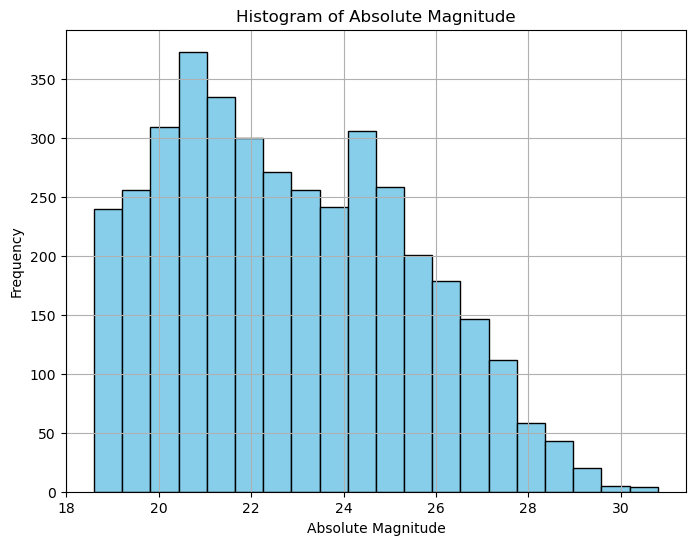

In [133]:
import matplotlib.pyplot as plt

# Plot histogram of Absolute Magnitude
plt.figure(figsize=(8, 6))
plt.hist(new_df['Absolute_Magnitude'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Absolute Magnitude')
plt.xlabel('Absolute Magnitude')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


    In the hitogram above,  the x-axis shows the absolute magnitude, ranging from 15 to 30 while the y-axis shows the frequency. The most frequent absolute magnitude values fall around 20.It explains that asteroids with the absolute magnite of 20 and 23 are quite high in number ranging from 590 to 750 while asteroids with absolute magnitude below 15 and above 30 are very few in numbers

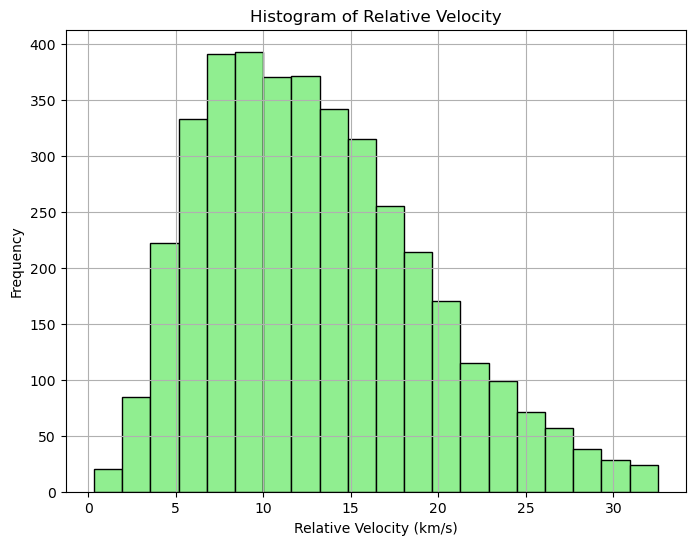

In [134]:
# Plot histogram of Relative Velocity
plt.figure(figsize=(8, 6))
plt.hist(new_df['relative_velocity(kmps)'], bins=20, color='lightgreen', edgecolor='black')
plt.title('Histogram of Relative Velocity')
plt.xlabel('Relative Velocity (km/s)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


    From the above graph, we can observe that the range of relative velocities between 10 and 20 km/s is the most common while at greater and lower relative velocities, fewer observations are made.
    There are more observations of greater relative velocities than of lower relative velocities due to the data's rightward bias.

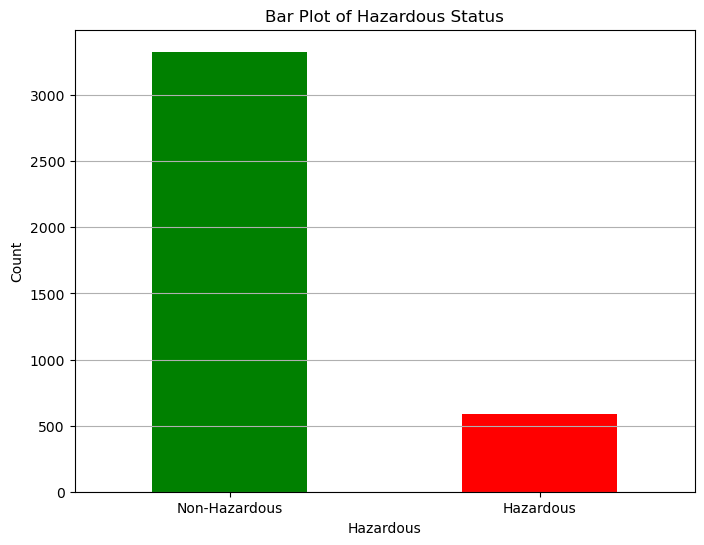

In [135]:
# Plot bar plot of Hazardous Status
hazardous_counts = new_df['Hazardous'].value_counts()
plt.figure(figsize=(8, 6))
hazardous_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Bar Plot of Hazardous Status')
plt.xlabel('Hazardous')
plt.ylabel('Count')
plt.xticks([0, 1], ['Non-Hazardous', 'Hazardous'], rotation=0)
plt.grid(axis='y')
plt.show()


    Here y-axis shows the count of asteroids, and the x-axis shows the status (hazardous or non-hazardous).  There were more non-hazardous asteroids than hazardous ones in the time period this data covers.Hazardous asteroids are around 750 while the number of non-hazardous asteroids is closer to 400. 

2 variable

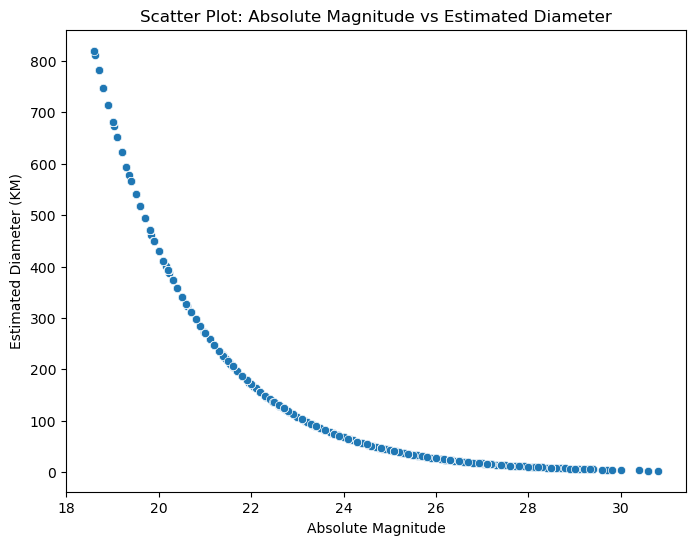

In [136]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=new_df, x='Absolute_Magnitude', y='estimated_diameter')
plt.title('Scatter Plot: Absolute Magnitude vs Estimated Diameter')
plt.xlabel('Absolute Magnitude')
plt.ylabel('Estimated Diameter (KM)')
plt.show()


    The above plot between the absolute magnitude and the estimated minimum diameter of celestial objects in the dataset is visualized visually by the scatter plot. The y-axis indicates the estimated minimum diameter of the objects in kilometers, while the x-axis shows the absolute magnitude, which is a measure of an object's brightness. With the x-coordinate representing absolute magnitude and the y-coordinate representing the estimated minimum diameter, each data point in the scatter plot represents an observation from the dataset. 

    We can observe above that the absolute magnitude and estimated diameter have a weakly negative association. This indicates that objects with higher absolute magnitude values, which are dimmer, typically have larger diameters.
    The fact that the data points are dispersed throughout the plot indicates that the association is somewhat variable. Certain small objects are brilliant, while some enormous objects are dim.

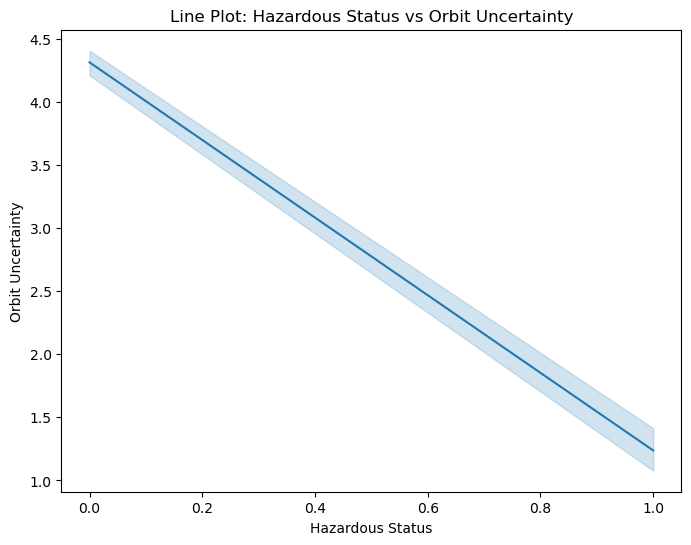

In [137]:
plt.figure(figsize=(8, 6))
sns.lineplot(data=new_df, x='Hazardous', y='Orbit_Uncertainty')
plt.title('Line Plot: Hazardous Status vs Orbit Uncertainty')
plt.xlabel('Hazardous Status')
plt.ylabel('Orbit Uncertainty')
plt.show()


    The code generates a line plot that illustrates the relationship between the hazardous status of celestial objects and the level of orbit uncertainty. The x-axis represents the hazardous status, indicating whether an object is hazardous or not, while the y-axis denotes the orbit uncertainty, which measures the level of uncertainty associated with the orbit of the objects. The line plot connects data points corresponding to different hazardous statuses, providing a visual depiction of how orbit uncertainty varies with the hazardous status of celestial objects. There is a positive correlation between orbit uncertainty and hazardous state, as indicated by the line figure. This implies that objects are typically categorized as more dangerous when their orbit is more unclear. This may be due to a few factors:

    It is challenging to predict with certainty whether an object will strike Earth if scientists are uncertain about its orbit.
    A slight alteration in an object's trajectory might cause it to collide with Earth even if it is unlikely for its orbit to cross ours.

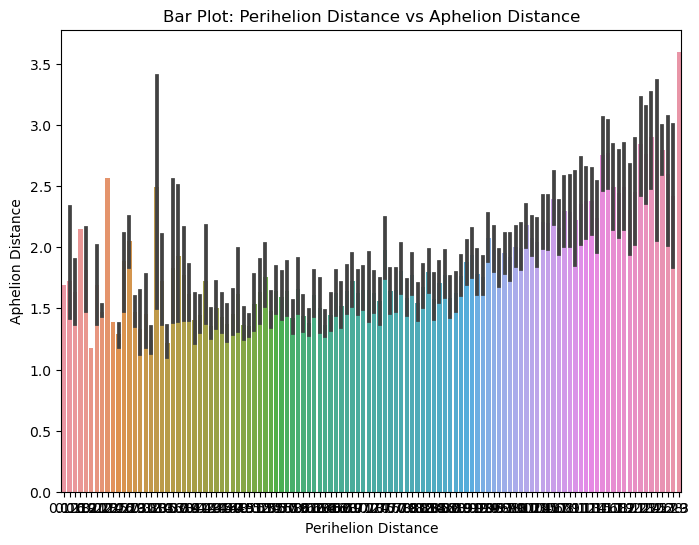

In [138]:
plt.figure(figsize=(8, 6))
sns.barplot(data=new_df, x='Perihelion_Distance', y='Aphelion_Distance')
plt.title('Bar Plot: Perihelion Distance vs Aphelion Distance')
plt.xlabel('Perihelion Distance')
plt.ylabel('Aphelion Distance')
plt.show()


    The bar graph that contrasts the dataset's celestial objects' perihelion and aphelion distances. The distance between an object and the sun during its orbit is measured along the x-axis, which represents the perihelion distance; the distance along the y-axis, on the other hand, indicates the aphelion distance, which is the farthest distance. The height of the bar shows the corresponding aphelion distance value, and each bar in the plot corresponds to a distinct perihelion distance value.

3 variable

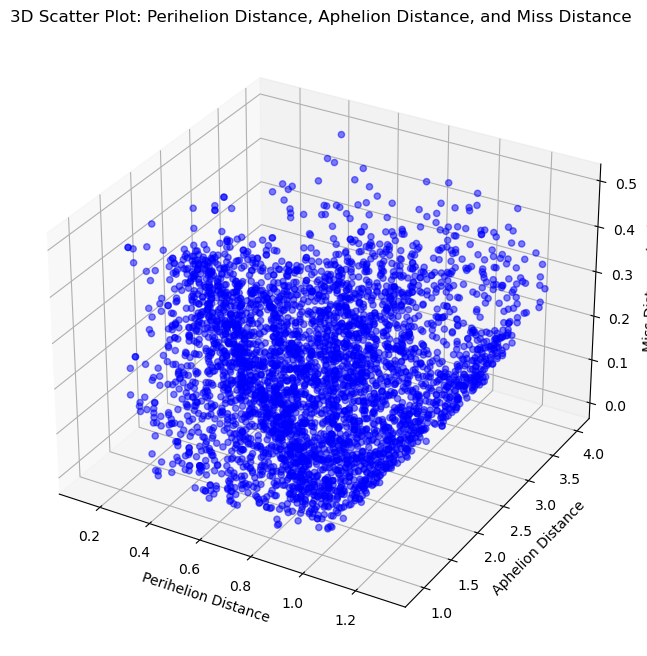

In [139]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(new_df['Perihelion_Distance'], new_df['Aphelion_Distance'], new_df['Miss_Distance(AU)'], c='blue', marker='o', alpha=0.5)
ax.set_xlabel('Perihelion Distance')
ax.set_ylabel('Aphelion Distance')
ax.set_zlabel('Miss Distance (AU)')
ax.set_title('3D Scatter Plot: Perihelion Distance, Aphelion Distance, and Miss Distance')
plt.show()

    The code provided creates a three-dimensional scatter map that illustrates the correlation between the dataset's celestial objects' perihelion, aphelion, and miss distances. The perihelion distance, or the closest distance an object can go to the sun throughout its orbit, is represented by the x-axis. The aphelion distance, or the furthest point on an object's orbit around the sun, is represented by the y-axis. The miss distance, expressed in astronomical units (AU), is represented by the z-axis and shows the object's closest approach to Earth throughout its orbit. Every data point in the scatter plot represents a celestial object, and its position is ascertained by its miss, aphelion, and perihelion distances.

    The following are some observations on the plot's data:

    Because of the elongated cloud of points in the z-direction, the miss distances of the majority of the objects are significantly greater than their perihelion or aphelion distances. This indicates that most objects in their orbits do not pass particularly close to Earth.
    Astronomers researching near-Earth objects (NEOs) may find interest in a few objects with substantially smaller miss distances.

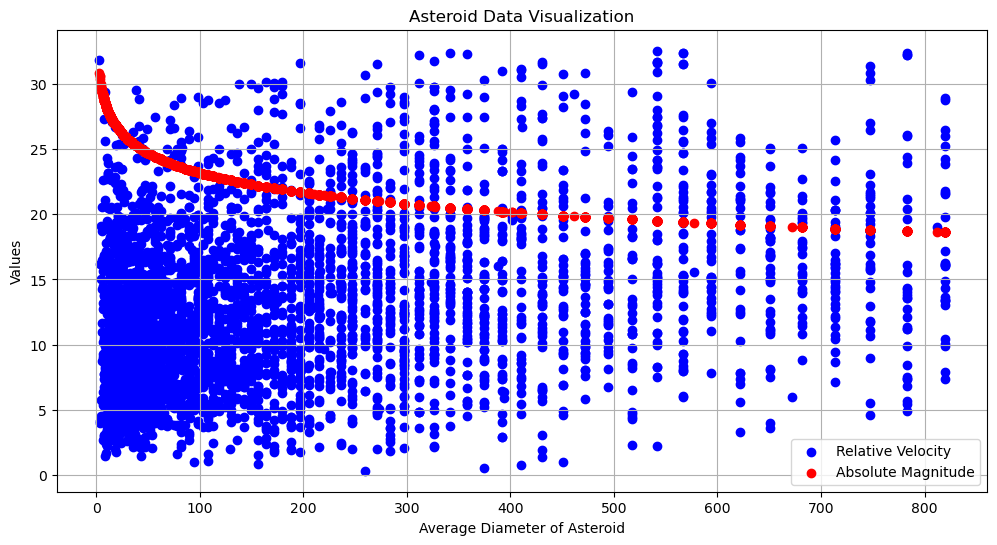

In [141]:
import pandas as pd
import matplotlib.pyplot as plt


# Plot the data
plt.figure(figsize=(12, 6))
plt.scatter(new_df['estimated_diameter'], new_df['relative_velocity(kmps)'], c='blue', label='Relative Velocity')
plt.scatter(new_df['estimated_diameter'], new_df['Absolute_Magnitude'], c='red', label='Absolute Magnitude')
plt.xlabel('Average Diameter of Asteroid')
plt.ylabel('Values')
plt.title('Asteroid Data Visualization')
plt.legend()
plt.grid(True)
plt.show()

Studying asteroids offers valuable insights into several aspects:

    Solar System Formation: Asteroids serve as remnants of the early solar system, providing essential clues about its formation. By analyzing asteroids, scientists can glean information about the composition of the solar nebula, shedding light on the conditions during the solar system's infancy.
    Resource Potential: Some asteroids are thought to harbor water ice and other essential materials. This makes them potential reservoirs for resources crucial for future space exploration endeavors. Accessing these resources could significantly advance our capabilities beyond Earth.
    Planetary Defense: Despite the rarity of large asteroid collisions with Earth, the potential threat they pose is taken seriously by scientists. Studying asteroids helps us understand their orbits better, enabling the development of strategies to deflect any hazardous asteroids on a collision course with our planet.
    In summary, asteroids present an intriguing opportunity to deepen our understanding of the solar system. Regarding the data plot you provided, while it may suggest a trend in the estimated asteroid diameter, the absence of axis labels makes it challenging to interpret conclusively.

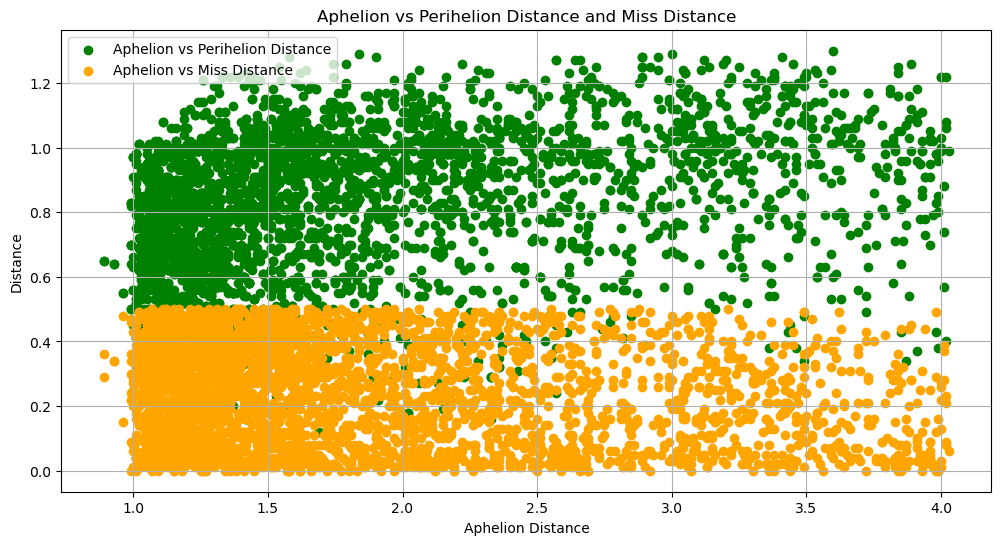

In [142]:
plt.figure(figsize=(12, 6))
plt.scatter(new_df['Aphelion_Distance'], new_df['Perihelion_Distance'], c='green', label='Aphelion vs Perihelion Distance')
plt.scatter(new_df['Aphelion_Distance'], new_df['Miss_Distance(AU)'], c='orange', label='Aphelion vs Miss Distance')
plt.xlabel('Aphelion Distance')
plt.ylabel('Distance')
plt.title('Aphelion vs Perihelion Distance and Miss Distance')
plt.legend()
plt.grid(True)
plt.show()

Regarding the graph's implications concerning aphelion distance:

    The x-axis presumably denotes aphelion distance, likely measured in astronomical units (AU). An AU signifies the average distance between the Earth and the Sun.
    The y-axis appears to represent a form of distance measurement, yet the absence of a label prevents definitive identification of its units.
    A subtle positive correlation is observed between aphelion distance and the y-axis measurement. This suggests that as the aphelion distance increases, the corresponding distance on the y-axis tends to rise.
    It's essential to acknowledge that without clarification on the meaning of "Miss Distance" and the lack of a y-axis label, a comprehensive understanding of the relationship between these variables remains elusive.

##### Review of the Literature: Developments in Asteroid Science

    Astronomers and planetary scientists have long been captivated by asteroids, which are leftovers of the primordial solar system. Our knowledge of these celestial entities has grown over time as a result of a multitude of studies on a variety of topics, including their composition, possible collision dangers, and implications for planetary formation. Based on the publications and conference papers provided, we will analyze significant discoveries and developments in asteroid study in this assessment of the literature.

Classification and Features of Asteroids

    Sorting asteroids according to their sizes, compositions, and orbital parameters is a basic component of asteroid studies. Important information about the features and classification of asteroids that cross Earth can be found in the studies written by Harris and Helin. In his discussion of the blurring lines separating asteroids, comets, and meteors, Harris emphasizes how difficult it is to define these things. Helin, on the other hand, emphasizes the breakthroughs in observational techniques that have enabled the finding of asteroids that cross Earth.

Sources and Construction

    Deciphering the origins and creation methods of asteroids is essential to understanding the solar system's early past. Harris discusses the P/Shoemaker-Levy 9 origins, highlighting the significance of examining its physical characteristics in order to obtain understanding of the processes involved in the genesis of the outer solar system. A historical summary of Earth-crossing asteroid findings is also included in Helin's paper, which traces the development of our knowledge of these objects over the previous 100 years.

Impact Hazard Evaluation

    Scientists and decision-makers alike are paying attention to asteroids because they pose a serious risk to Earth. Harris talks on how asteroids affect the atmosphere, with an emphasis on the numerical modeling of crashes into Jupiter. Researchers can learn more about impact dynamics and possible Earth-related ramifications by examining these occurrences. Harris also calls into question whether impact theories can be tested, emphasizing the importance of thorough observational validation.

Structure and Composition

    Important details regarding the origins and evolutionary history of asteroids can be learned by examining their composition and structure. The existence of silicate compounds is indicated by the spectrum signatures of non-volatile components found in the nucleus of P/Shoemaker-Levy 9, as mentioned by Harris. This discovery highlights the variety of asteroid compositions and their intricate evolutionary histories. In order to offer information on the physical characteristics of asteroids that traverse Earth, Helin's article also examines the sizes and colors of these objects.

Prospective Courses


    Asteroid research is expected to continue developing and evolving in the future. In order to improve our comprehension of asteroid dynamics and origins, Harris highlights the significance of continuing observations and analysis. Similar to this, Helin emphasizes the necessity of conducting systematic searches and utilizing cutting-edge observational methods in order to find and identify new asteroids that cross the Earth. Through the integration of theoretical models with empirical data, scientists might enhance our comprehension of these mysterious objects.

In summary

    To sum up, the examined articles and conference papers offer insightful information on a range of asteroid study topics, such as composition, impact dynamics, categorization, and origins. Through the integration of theoretical modeling and observational data, scientists are making noteworthy progress in deciphering the enigmas surrounding asteroids and their influence on solar system formation. A fascinating and active topic of research, asteroids promise to continue as technology develops and our understanding grows.

##### References    
    Harris, A. W. (1996). Conference Summary: Asteroids. Earth, Moon, and Planets, 72, 489-492.

   Helin, E. F. (1982). Earth-Crossing Asteroids: New Discoveries. In W. Fricke & G. Teleki (Eds.), Sun and Planetary System (pp. 269-276). D. Reidel Publishing Company.

   Hanna, R. D., Ketcham, R. A., Zolensky, M., and Behr, W. M. (2015) Impact-induced Brittle Deformation, Porosity Loss, and Aqueous Alteration in the Murchison CM Chondrite, Geochimica et Cosmochimica Acta, v. 171, p. 256-282, doi: 10.1016/j.gca.2015.09.005

   Sears, D. W. G. (2015) The Explored Asteroids: Science and Exploration in the Space Age, Space Science Review, v. 194, p. 139-235, doi: 10.1007/s11214-015-0202-7

   Greenwood, R. C., Burbine, T. H., Miller, M. F., and Franchi, I. A.. (2016) Melting and Differentiation of Early-Formed Asteroids: The Perspective from High Precision Oxygen Isotope Studies, Chemie der Erde, available online 14 NOV 2016, doi: 10.1016/j.chemer.2016.09.005

   Helin, E. F., & Shoemaker, E. M. (1979). The Palomar Planet-Crossing Asteroid Survey, 1973–1978. Icarus, 40, 321–328.

 Hulkower, N. D. (1980). Rendezvous with 1980 PA: Preliminary data. JPL Interoffice Memorandum 312/80.4–641, 2 September 1980.

   Hulkower, N. D., & Ross, D. J. (1981). A mission to rendezvous with Anteros. AIAA-81–0314.

  Lebofsky, L. A., Lebofsky, M. J., & Rieke, G. H. (1979). Radiometry and surface properties of Apollo, Amor and Aten asteroids. Astron. J., 84, 8857–888.

  Marsden, B. G. (1979). 1947 XC = 1979 XA. Internat. Astronom. Circ. No. 3432.

  Minor Planet Circular Nos. 4823 and 5006. (1979).

  Morrison, D., Gradie, J. C., & Rieke, G. H. (1976). Radiometric diameter and albedo of the remarkable asteroid 1976 AA. Nature, 260, 691.

 Niehoff, J. C. (1977). Round-trip mission requirements for asteroids 1976 AA and 1973 EC. Icarus, 31, 430–438.

 Shoemaker, E. M., & Helin, E. F. (1978b). Earth-approaching asteroids as targets for exploration. NASA Conf. Publ. 2053, 245–256.

Shoemaker, E. M., William, J. G., Helin, E. F., & Wolfe, R. F. (1979). Earth-crossing asteroids: Orbital classes, collision rates with Earth, and origin. In T. Gehrels (Ed.), Asteroids. Univ. Ariz. Press, Tucson, Arizona, 253–282.

Stancati, M. L., & Soldner, J. K. (1981). Near Earth asteroids: A survey of ballistic rendezvous and sample return missions. AAS Paper 81–185, 1–16.

Wetherill, G. W. (1976). Where do the meteorites come from: A reevaluation of the Earth-crossing Apollo objects as sources of chondritic meteorites. Geochim. et. Cosmochemi. Acta, 40, 1297–1317.

Whipple, F. L. (1973). Note on the number and origin of Apollo asteroids. The Moon, 8, 340–345

Granvik, M., Vaubaillon, J., and Jedicke, R. (2012) The Population of Natural Earth Satellites, Icarus, v. 218, p. 262-277

Taylor, G. J. (2004, April 2). Kernouve Asteroid Heating: A Shocking View. Planetary Science Research Discoveries. Retrieved from http://www.psrd.hawaii.edu/April04/asteroidHeating.html



Martel, L. M. V. (2002, June 28). Using Chondrites to Understand the Inside of Asteroid 433 Eros. Planetary Science Research Discoveries. http://www.psrd.hawaii.edu/



Martel, L. (November 2014). Tracking Asteroids—Watching the Sky—Searching for Meteorites. Planetary Science Research Discoveries. http://www.psrd.hawaii.edu/


Taylor, G. J. (2008, July). Heating, cooling, and cratering: One asteroid's complicated story. Planetary Science Research Discoveries. Retrieved from http://www.psrd.hawaii.edu/July08/H-chondrite-parent.html

Taylor, G. J. (2015, January). Water in Asteroid 4 Vesta. Planetary Science Research Discoveries. http://www.psrd.hawaii.edu/Jan15/Vesta-water.html

Martel, L. M. V. (2010, April). Asteroid, Meteor, Meteorite. Planetary Science Research Discoveries. Retrieved from http://www.psrd.hawaii.edu/Apr10/AlmahataSitta.html

Taylor, G. J. (2000, November 21). Mining the Moon, Mars, and Asteroids. Planetary Science Research Discoveries. Retrieved from http://www.psrd.hawaii.edu/Nov00/MiningSpace.html



In [144]:
new_df.head()

,Absolute_Magnitude,relative_velocity(kmps),Miss_Distance(AU),Orbit_Uncertainty,Orbit_Intersection(min),Jupiter_Tisserand_Invariant,Perihelion_Distance,Aphelion_Distance,Anomaly(mean),Motion(mean),Hazardous,estimated_diameter
0,21.6,6.12,0.42,5,0.03,4.63,0.81,2.01,264.84,0.59,True,205.85
1,21.3,18.11,0.38,3,0.19,5.46,0.72,1.50,173.74,0.85,False,236.34
2,20.3,7.59,0.05,0,0.04,4.56,0.95,1.97,292.89,0.56,True,374.58
3,27.4,11.17,0.29,6,0.01,5.09,0.98,1.53,68.74,0.70,False,14.24
4,21.6,9.84,0.41,1,0.03,5.15,0.97,1.48,135.14,0.73,True,205.85


Saving the latest cleaned dataframe into a new csv file.

In [145]:
new_df.to_csv("new_nasa.csv", sep=',', index=False, encoding='utf-8')